In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/Kirin930/apple-diameter-estimator.git
!pip install -r /content/apple-diameter-estimator/requirements.txt
!python -m pip install /content/apple-diameter-estimator/detectron2 -U -q

Mounted at /content/drive
Cloning into 'apple-diameter-estimator'...
remote: Enumerating objects: 951, done.
remote: Counting objects: 100% (951/951), done.
remote: Compressing objects: 100% (745/745), done.
remote: Total 951 (delta 193), reused 947 (delta 192), pack-reused 0 (from 0)
Receiving objects: 100% (951/951), 1.11 MiB | 18.62 MiB/s, done.
Resolving deltas: 100% (193/193), done.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 66.1 MB/s eta 0:00:00


In [ ]:
#!/usr/bin/env python3
"""
Snapshot-style RGB-D training script (single file, no external imports).

- Config block at top (paths/hparams).
- COCO loader that keeps diameter + per-annotation depth_file, and remaps category_id contiguously.
- RGB-D mapper: no geometric augs, photometric only on RGB; depth in mm as 4th channel.
- ResNet50-FPN backbone patched for 4-channel input (early fusion, robust to re-runs).
- Inline DiameterROIHeads (@configurable): regress normalized diameter from RoI features + geometric cues
  [log_w, log_h, log_z, geom_mm_norm].
- Inline PeriodicValHook: MAE/RMSE on the validation set using GT boxes.

Assumptions:
- COCO annotations include: bbox, category_id, diameter_gt (or diameter_mm), depth_file
- Depth images are Z16 PNGs in millimetres.
"""

import os, json, random, math
from typing import Any, Dict, List
import numpy as np
import cv2
import torch
import torch.nn as nn
from torch.nn import functional as F

from detectron2 import model_zoo
from detectron2.config import get_cfg, configurable
from detectron2.engine import DefaultTrainer, HookBase, default_setup
from detectron2.data import (
    DatasetCatalog, MetadataCatalog,
    build_detection_train_loader, build_detection_test_loader,
    detection_utils as utils, transforms as T,
)
from detectron2.structures import Instances, Boxes, BoxMode
from detectron2.utils.events import CommonMetricPrinter, JSONWriter

from detectron2.modeling.backbone import BACKBONE_REGISTRY
from detectron2.modeling.backbone.resnet import BasicStem
from detectron2.modeling.backbone.fpn import build_resnet_fpn_backbone
from detectron2.modeling.poolers import ROIPooler
from detectron2.modeling.roi_heads import ROIHeads, ROI_HEADS_REGISTRY
from detectron2.layers import Conv2d
from detectron2.checkpoint import DetectionCheckpointer


# =========================================================
# ===================== CONFIG BLOCK ======================
# =========================================================
TRAIN_JSON   = "/content/drive/MyDrive/snapshots_dataset/annotations/instances_Train.json"
EVAL_JSON    = "/content/drive/MyDrive/snapshots_dataset/annotations/instances_Eval.json"
IMG_ROOT     = "/content/drive/MyDrive/snapshots_dataset/rgb"
DEPTH_ROOT   = "/content/drive/MyDrive/snapshots_dataset/depth"

OUTPUT_DIR   = "/content/drive/MyDrive/snapshots_dataset/output_rgbd"
MAX_ITER     = 32000
BATCH        = 2
BASE_LR      = 2e-4
WARMUP_FRAC  = 0.02
EVAL_PERIOD  = 1000
SEED         = 42

# Camera / geometry
FX_PX        = 600.0
SCALE_MM     = 70.0

# Augmentations: snapshot style (no geometry, solo photometric su RGB)
ENABLE_PHOTOMETRIC = True

# 4th channel normalization (depth in mm) — dai tuoi valori stimati
PIXEL_MEAN = [103.53, 116.28, 123.675, 192.723]
PIXEL_STD  = [57.375, 57.12,  58.395,  80.738]

# ROI head settings
POOLER_RESOLUTION = 14
HIDDEN_DIM = 1024
HIDDEN_DIM_2 = 256
HUBER_DELTA = 1.0           # Huber loss delta su unità normalizzate
RESIDUAL_L2 = 0.0           # >0 per spingere residual piccolo rispetto al prior geometrico
DROPOUT_P   = 0.0
# =========================================================


# ===== category mapping (global) =====
_ID_TO_CONTIG = None        # es. {1:0, 3:1, ...}
_THING_CLASSES = None       # es. ["apple"] in ordine contiguo

def _build_category_mapping(json_path: str):
    """Legge categories dal COCO e costruisce:
       - _ID_TO_CONTIG: mappa id COCO -> indice contiguo [0..K-1]
       - _THING_CLASSES: nomi in ordine contiguo
    """
    global _ID_TO_CONTIG, _THING_CLASSES
    with open(json_path, "r") as f:
        coco = json.load(f)

    cats = coco.get("categories", [])
    if not cats:
        # fallback: singola classe 'apple'
        _ID_TO_CONTIG = {0: 0, 1: 0}
        _THING_CLASSES = ["apple"]
        return

    cats_sorted = sorted(cats, key=lambda c: c.get("id", 0))
    _ID_TO_CONTIG = {c["id"]: i for i, c in enumerate(cats_sorted)}
    _THING_CLASSES = [c.get("name", str(c["id"])) for c in cats_sorted]


# ---------------------- dataset loader ----------------------
def load_coco_with_diameter(json_path: str, img_root: str) -> List[Dict[str, Any]]:
    with open(json_path, "r") as f:
        coco = json.load(f)

    imgs = {im["id"]: im for im in coco["images"]}
    anns_by_img: Dict[int, List[Dict[str, Any]]] = {}
    for ann in coco["annotations"]:
        if ann.get("iscrowd", 0) == 1:
            continue
        if "bbox" not in ann or len(ann["bbox"]) != 4:
            continue

        if "diameter_mm" in ann:
            dmm = float(ann["diameter_mm"])
        elif "diameter_gt" in ann:
            dmm = float(ann["diameter_gt"])
        else:
            continue

        # ---- remap category_id to contiguous ----
        raw_cid = ann.get("category_id", 0)
        cid = _ID_TO_CONTIG.get(raw_cid, 0) if _ID_TO_CONTIG is not None else 0

        depth_file = ann.get("depth_file", None)
        anns_by_img.setdefault(ann["image_id"], []).append({
            "bbox": ann["bbox"],
            "category_id": cid,
            "diameter_mm": dmm,
            "depth_file": depth_file,
        })

    dataset = []
    for img_id, im in imgs.items():
        file_name = os.path.join(img_root, im["file_name"])
        rec = {
            "file_name": file_name,
            "image_id": img_id,
            "height": im["height"],
            "width":  im["width"],
            "annotations": anns_by_img.get(img_id, []),
        }
        dfs = [a["depth_file"] for a in rec["annotations"] if a.get("depth_file")]
        if dfs:
            rec["depth_file"] = dfs[0]
        dataset.append(rec)
    return dataset


# ------------------------ helpers ------------------------
def _to_single_channel(arr: np.ndarray) -> np.ndarray:
    """Force depth to 2D: squeeze 1-channel or take channel 0 if 3-channel/colorized."""
    if arr is None:
        return None
    a = np.asarray(arr)
    # If colorized (HxWx3 or more), take first channel
    if a.ndim == 3 and a.shape[2] >= 3:
        a = a[..., 0]
    # Squeeze leftover singleton dims (HxWx1 -> HxW, HxWx1x1 -> HxW, etc.)
    if a.ndim > 2:
        a = np.squeeze(a)
    return a

def _read_depth_mm(path: str) -> np.ndarray:
    """Read depth PNG; return float32 millimetres; zeros→NaN. Robust to 3-ch colorized files."""
    if not path:
        return None
    d = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if d is None:
        return None
    d = _to_single_channel(d)
    dm = d.astype(np.float32)
    dm[dm == 0] = np.nan
    return dm

def _read_depth_m(path: str) -> np.ndarray:
    """Meters (for geometric cues). Robust to 3-ch colorized files."""
    if not path:
        return None
    d = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if d is None:
        return None
    d = _to_single_channel(d)
    dm = d.astype(np.float32)
    if dm.max() > 50.0:
        dm = dm / 1000.0
    return dm

def _resize_depth_like(depth_arr: np.ndarray, H: int, W: int) -> np.ndarray:
    if depth_arr is None:
        return None
    return cv2.resize(depth_arr, (W, H), interpolation=cv2.INTER_NEAREST)

def _depth_stat_in_box(depth_m: np.ndarray, x: float, y: float, w: float, h: float,
                       H: int, W: int) -> float:
    x0 = max(int(x), 0); y0 = max(int(y), 0)
    x1 = min(int(x + w), W); y1 = min(int(y + h), H)
    if x1 <= x0 or y1 <= y0 or depth_m is None:
        return 0.0
    crop = depth_m[y0:y1, x0:x1]
    v = crop[np.isfinite(crop) & (crop > 0)]
    if v.size == 0:
        return 0.0
    return float(np.median(v))

def _pinhole_mm(px_w: float, z_m: float, fx_px: float) -> float:
    if z_m <= 0.0 or fx_px <= 0.0: return 0.0
    return float(px_w * (z_m / fx_px) * 1000.0)

def _numpy_to_torch_state_dict(sd):
    """
    Detectron2 model_zoo checkpoints (.pkl) often store params as NumPy arrays.
    Convert all leaves to torch.Tensor so load_state_dict() accepts them.
    Accepts either a flat dict or a dict with key 'model'.
    Returns a flat dict of torch.Tensors.
    """
    if "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]

    out = {}
    for k, v in sd.items():
        if isinstance(v, torch.Tensor):
            out[k] = v
        elif isinstance(v, np.ndarray):
            out[k] = torch.from_numpy(v)
        else:
            try:
                out[k] = torch.as_tensor(v)
            except Exception:
                continue
    return out


# -------------------- RGB-D mapper (snapshot style) --------------------
def mapper_rgbd(dataset_dict: Dict[str, Any]) -> Dict[str, Any]:
    d = dataset_dict.copy()
    rgb_bgr = utils.read_image(d["file_name"], format="BGR").astype(np.float32)
    H, W = rgb_bgr.shape[:2]

    # Photometric-only on RGB
    if ENABLE_PHOTOMETRIC:
        aug = T.AugmentationList([
            T.RandomBrightness(0.9, 1.1),
            T.RandomContrast(0.9, 1.1),
            T.RandomSaturation(0.9, 1.1),
        ])
        ain = T.AugInput(rgb_bgr)
        _ = aug(ain)
        rgb_bgr = ain.image

    # Depth path (relative to DEPTH_ROOT if not absolute)
    dp = d.get("depth_file")
    depth_path = None
    if dp:
        depth_path = dp if os.path.isabs(dp) else os.path.join(DEPTH_ROOT, dp)

    # ---- Depth channel in mm (robusto a 3-ch, 1x1, ecc.) ----
    depth_mm = _read_depth_mm(depth_path)
    depth_mm = _resize_depth_like(depth_mm, H, W)
    if depth_mm is None:
        depth_mm = np.full((H, W), np.nan, dtype=np.float32)
    else:
        depth_mm = np.asarray(depth_mm)
        # se 3-ch (colorized), usa il primo canale; squeeze il resto
        if depth_mm.ndim == 3 and depth_mm.shape[2] >= 3:
            depth_mm = depth_mm[..., 0]
        if depth_mm.ndim > 2:
            depth_mm = np.squeeze(depth_mm)
        if depth_mm.ndim != 2:
            if depth_mm.size == H * W:
                depth_mm = depth_mm.reshape(H, W)
            else:
                depth_mm = cv2.resize(depth_mm.astype(np.float32), (W, H), interpolation=cv2.INTER_NEAREST)
        depth_mm = depth_mm.astype(np.float32)

    # riempi NaN con mediana (o 0 se tutto NaN)
    if np.isnan(depth_mm).any():
        med = np.nanmedian(depth_mm) if np.isfinite(depth_mm).any() else 0.0
        depth_mm = np.where(np.isnan(depth_mm), med, depth_mm)

    # ---- Build [4,H,W] senza concatenate (evita mismatch dimensioni) ----
    rgb_rgb = cv2.cvtColor(rgb_bgr.astype(np.uint8), cv2.COLOR_BGR2RGB).astype(np.float32)  # [H,W,3]
    rgbd = np.empty((H, W, 4), dtype=np.float32)
    rgbd[..., :3] = rgb_rgb
    rgbd[..., 3]  = depth_mm
    image = torch.as_tensor(rgbd.transpose(2, 0, 1))  # [4,H,W]

    # Normalize
    mean = torch.tensor(np.array(PIXEL_MEAN, dtype=np.float32).reshape(4,1,1))
    std  = torch.tensor(np.array(PIXEL_STD,  dtype=np.float32).reshape(4,1,1))
    image = (image - mean) / std

    # ---- Instances + geometric cues (depth in meters con stesso forcing) ----
    annos = []
    xyxy  = []
    cues  = []  # [log_w, log_h, log_z, geom_mm_norm]
    depth_m = _read_depth_m(depth_path)
    depth_m = _resize_depth_like(depth_m, H, W)
    if depth_m is not None:
        depth_m = np.asarray(depth_m)
        if depth_m.ndim == 3 and depth_m.shape[2] >= 3:
            depth_m = depth_m[..., 0]
        if depth_m.ndim > 2:
            depth_m = np.squeeze(depth_m)
        if depth_m.ndim != 2:
            if depth_m.size == H * W:
                depth_m = depth_m.reshape(H, W)
            else:
                depth_m = cv2.resize(depth_m.astype(np.float32), (W, H), interpolation=cv2.INTER_NEAREST)
        depth_m = depth_m.astype(np.float32)

    for a in d.get("annotations", []):
        x, y, w, h = a["bbox"]
        xyxy.append([x, y, x+w, y+h])

        gt_d_norm = float(a["diameter_mm"]) / SCALE_MM
        z_m = _depth_stat_in_box(depth_m, x, y, w, h, H, W) if depth_m is not None else 0.0
        log_z = float(np.log(max(z_m, 1e-6)))
        geom_mm = _pinhole_mm(w, z_m, FX_PX)
        geom_norm = float(geom_mm / SCALE_MM)

        cues.append([np.log(max(w,1e-6)), np.log(max(h,1e-6)), log_z, geom_norm])
        annos.append({
            "bbox": [x, y, w, h],
            "bbox_mode": BoxMode.XYWH_ABS,
            "category_id": a.get("category_id", 0),
            "diameter_norm": gt_d_norm
        })

    instances = utils.annotations_to_instances(annos, (H, W))
    if xyxy:
        instances.gt_boxes = Boxes(torch.tensor(xyxy, dtype=torch.float32))
        instances.set("diameter_norm", torch.tensor([a["diameter_norm"] for a in annos], dtype=torch.float32))
        instances.set("geom_cues",     torch.tensor(cues, dtype=torch.float32))

    d["image"] = image
    d["instances"] = instances
    return d


# ---------------------- 4-ch ResNet-FPN backbone ----------------------
class BasicStem4(BasicStem):
    def __init__(self, in_channels=4, out_channels=64, norm="FrozenBN"):
        super().__init__(in_channels=in_channels, out_channels=out_channels, norm=norm)

@BACKBONE_REGISTRY.register()
def build_resnet_fpn_backbone_rgbd_v1(cfg, input_shape):
    """
    Build a ResNet-FPN backbone then patch bottom_up.stem.conv1 to 4 channels, robustly.
    """
    backbone = build_resnet_fpn_backbone(cfg, input_shape)  # FPN
    old_conv: nn.Conv2d = backbone.bottom_up.stem.conv1

    out_ch  = old_conv.out_channels
    k, s, p, d = old_conv.kernel_size, old_conv.stride, old_conv.padding, old_conv.dilation
    bias = old_conv.bias is not None

    new_conv = Conv2d(
        in_channels=4,
        out_channels=out_ch,
        kernel_size=k,
        stride=s,
        padding=p,
        dilation=d,
        bias=bias,
        norm=None,
        activation=None,
    )

    with torch.no_grad():
        w_old = old_conv.weight  # [out_ch, Cin_old, k, k]
        Cin_old = w_old.shape[1]
        if Cin_old == 3:
            new_conv.weight[:, :3, :, :] = w_old
            new_conv.weight[:, 3:4, :, :] = w_old.mean(dim=1, keepdim=True)
        elif Cin_old == 4:
            new_conv.weight.copy_(w_old)
        else:
            c = min(Cin_old, 4)
            new_conv.weight[:, :c, :, :] = w_old[:, :c, :, :]
            fill = w_old.mean(dim=1, keepdim=True)
            if c < 4:
                new_conv.weight[:, c:4, :, :] = fill
        if bias and old_conv.bias is not None:
            new_conv.bias.copy_(old_conv.bias)

    backbone.bottom_up.stem.conv1 = new_conv

    print(f"[DEBUG] bottom_up.stem.conv1 weight shape -> {backbone.bottom_up.stem.conv1.weight.shape}")
    print(f"[DEBUG] FPN output features -> {list(backbone.output_shape().keys())}")
    return backbone


# ---------------------- ROI HEAD (INLINE, @configurable) ----------------------
@ROI_HEADS_REGISTRY.register()
class DiameterROIHeads(ROIHeads):
    """
    Minimal ROI heads that:
     - use GT boxes during training (no RPN interaction),
     - pool FPN features over GT boxes,
     - fuse pooled features + geometric cues and predict normalized diameter,
     - compute Smooth L1 (Huber) on normalized units; optional L2 on residual vs geom prior.
    """

    @configurable
    def __init__(self, *, cfg, input_shape, **kwargs):
        # Base ROIHeads expects kwargs from ROIHeads.from_config(cfg)
        super().__init__(**kwargs)

        self.in_features = cfg.MODEL.ROI_HEADS.IN_FEATURES
        self.pooler = ROIPooler(
            output_size=cfg.MODEL.ROI_BOX_HEAD.POOLER_RESOLUTION,
            scales=tuple(1.0 / input_shape[f].stride for f in self.in_features),
            sampling_ratio=cfg.MODEL.ROI_BOX_HEAD.POOLER_SAMPLING_RATIO,
            pooler_type=cfg.MODEL.ROI_BOX_HEAD.POOLER_TYPE,
        )
        in_channels = [input_shape[f].channels for f in self.in_features][0]
        rep = cfg.MODEL.ROI_BOX_HEAD.POOLER_RESOLUTION
        flat_dim = in_channels * rep * rep

        self.mlp = nn.Sequential(
            nn.Linear(flat_dim + 4, HIDDEN_DIM),
            nn.ReLU(inplace=True),
            nn.Dropout(p=DROPOUT_P) if DROPOUT_P > 0 else nn.Identity(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM_2),
            nn.ReLU(inplace=True),
            nn.Linear(HIDDEN_DIM_2, 1),
        )

        self.huber_delta = HUBER_DELTA
        self.residual_l2 = RESIDUAL_L2

    @classmethod
    def from_config(cls, cfg, input_shape=None):
        base_kwargs = ROIHeads.from_config(cfg)          # version that takes only cfg
        base_kwargs.update({"cfg": cfg, "input_shape": input_shape})
        return base_kwargs

    def _pool(self, features, boxes):
        feats = [features[f] for f in self.in_features]
        return self.pooler(feats, boxes)

    def forward(self, images, features, proposals, targets=None):
        train = self.training
        insts = targets if train and targets is not None else proposals

        boxes = [i.gt_boxes if i.has("gt_boxes") else i.proposal_boxes for i in insts]
        pooled = self._pool(features, boxes)
        N = pooled.shape[0]
        if N == 0:
            return proposals, {} if train else (proposals, [])

        x = pooled.flatten(start_dim=1)
        if not insts[0].has("geom_cues"):
            raise ValueError("Instances missing 'geom_cues' field.")
        cues = torch.cat([i.get("geom_cues") for i in insts], dim=0)
        x = torch.cat([x, cues.to(x.device)], dim=1)

        pred = self.mlp(x).squeeze(1)

        if train:
            if not insts[0].has("diameter_norm"):
                raise ValueError("Instances missing 'diameter_norm' field.")
            target = torch.cat([i.get("diameter_norm") for i in insts], dim=0).to(pred.device)

            loss = F.smooth_l1_loss(pred, target, beta=self.huber_delta, reduction="mean")

            if self.residual_l2 > 0:
                geom = torch.cat([i.get("geom_cues") for i in insts], dim=0)[:, 3].to(pred.device)
                residual = pred - geom
                loss = loss + self.residual_l2 * torch.mean(residual * residual)

            return proposals, {"loss_diameter": loss}

        out = []
        idx = 0
        for inst in proposals:
            m = len(inst)
            if m == 0:
                out.append(inst); continue
            new_inst = Instances(inst.image_size, **inst.get_fields())
            d_norm = pred[idx:idx+m]
            d_mm = d_norm * SCALE_MM
            new_inst.set("pred_diameter_mm", d_mm.detach().cpu())
            out.append(new_inst)
            idx += m

        return out, {}


# ------------------------- trainer -------------------------
class MyTrainer(DefaultTrainer):
    @classmethod
    def build_train_loader(cls, cfg):
        return build_detection_train_loader(cfg, mapper=mapper_rgbd)

    def build_writers(self):
        os.makedirs(self.cfg.OUTPUT_DIR, exist_ok=True)
        return [
            CommonMetricPrinter(max_iter=self.cfg.SOLVER.MAX_ITER),
            JSONWriter(os.path.join(self.cfg.OUTPUT_DIR, "metrics.json")),
        ]


# --------------------- validation hook ---------------------
class PeriodicValHook(HookBase):
    def __init__(self, eval_period, json_path, img_root):
        self._period = eval_period
        self._json   = json_path
        self._img_root = img_root
        self._name  = "apples_eval"

        if self._name not in DatasetCatalog.list():
            DatasetCatalog.register(self._name, lambda: load_coco_with_diameter(self._json, self._img_root))
            MetadataCatalog.get(self._name).set(thing_classes=_THING_CLASSES or ["apple"])

    def after_step(self):
        next_iter = self.trainer.iter + 1
        if (self._period > 0) and (next_iter % self._period == 0 or next_iter == self.trainer.max_iter):
            self._run_eval()

    @torch.no_grad()
    def _run_eval(self):
        model = self.trainer.model
        model.eval()
        cfg = self.trainer.cfg
        val_loader = build_detection_test_loader(cfg, self._name, mapper=mapper_rgbd)

        abs_errs, sq_errs, n = 0.0, 0.0, 0
        for batch in val_loader:
            inputs = [{"image": b["image"], "instances": b["instances"]} for b in batch]
            images = model.preprocess_image(inputs)           # ImageList
            features = model.backbone(images.tensor)          # dict of FPN features

            targets = [x["instances"].to(images.tensor.device) for x in inputs]
            pred_insts, _ = model.roi_heads(images, features, proposals=targets, targets=targets)
            for tgt, pred in zip(targets, pred_insts):
                gt = tgt.get("diameter_norm") * SCALE_MM  # mm
                pr = pred.get("pred_diameter_mm")
                if gt is None or pr is None:
                    continue
                gt = gt.detach().cpu().numpy().astype(np.float32)
                pr = pr.detach().cpu().numpy().astype(np.float32)
                abs_errs += float(np.abs(pr - gt).sum())
                sq_errs  += float(((pr - gt) ** 2).sum())
                n        += gt.shape[0]

        if n > 0:
            mae = abs_errs / n
            rmse = math.sqrt(sq_errs / n)
            print(f"[Val] MAE(mm)={mae:.3f}  RMSE(mm)={rmse:.3f}  (N={n})")
            storage = self.trainer.storage
            storage.put_scalar("val_mae_mm", mae)
            storage.put_scalar("val_rmse_mm", rmse)

        model.train()


# ------------------------ config ---------------------------
def build_cfg():
    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
    cfg = get_cfg()
    cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))

    # 4-ch ResNet-FPN backbone
    cfg.MODEL.BACKBONE.NAME = "build_resnet_fpn_backbone_rgbd_v1"

    # Replace ROI heads with our inline head
    cfg.MODEL.ROI_HEADS.NAME = "DiameterROIHeads"
    cfg.MODEL.ROI_HEADS.IN_FEATURES = ["p2", "p3", "p4", "p5"]  # FPN levels
    cfg.MODEL.ROI_BOX_HEAD.POOLER_RESOLUTION = POOLER_RESOLUTION
    cfg.MODEL.ROI_BOX_HEAD.POOLER_SAMPLING_RATIO = 0
    cfg.MODEL.ROI_BOX_HEAD.POOLER_TYPE = "ROIAlignV2"
    # cfg.MODEL.ROI_HEADS.NUM_CLASSES will be set in main() from _THING_CLASSES

    # 4-channel normalization
    cfg.MODEL.PIXEL_MEAN = PIXEL_MEAN
    cfg.MODEL.PIXEL_STD  = PIXEL_STD

    # Datasets
    cfg.DATASETS.TRAIN = ("apples_train",)
    cfg.DATASETS.TEST  = ()
    cfg.DATALOADER.NUM_WORKERS = 2

    # Solver
    cfg.SOLVER.IMS_PER_BATCH = BATCH
    cfg.SOLVER.BASE_LR = BASE_LR
    cfg.SOLVER.MAX_ITER = MAX_ITER
    cfg.SOLVER.WARMUP_ITERS = max(10, int(WARMUP_FRAC * MAX_ITER))
    cfg.SOLVER.STEPS = []  # flat LR

    # Image sizes
    cfg.INPUT.MIN_SIZE_TRAIN = (800,)
    cfg.INPUT.MAX_SIZE_TRAIN = 1333
    cfg.INPUT.MIN_SIZE_TEST  = 800
    cfg.INPUT.MAX_SIZE_TEST  = 1333

    # Pretrained weights
    cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")

    cfg.OUTPUT_DIR = OUTPUT_DIR
    os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
    return cfg


# -------------------------- main --------------------------
def _expand_conv1_in_state_dict_to_4ch(state_dict):
    """
    Espande i pesi conv1 da 3→4 canali prima del load, se necessario.
    Prova sia il path FPN (bottom_up) che quello semplice.
    """
    keys = [
        "backbone.bottom_up.stem.conv1.weight",  # FPN
        "backbone.stem.conv1.weight",            # non-FPN fallback
    ]
    for key in keys:
        w = state_dict.get(key, None)
        if isinstance(w, torch.Tensor) and w.ndim == 4 and w.shape[1] == 3:
            w4 = torch.zeros((w.shape[0], 4, w.shape[2], w.shape[3]), dtype=w.dtype)
            w4[:, :3, :, :] = w
            w4[:, 3:4, :, :] = w.mean(dim=1, keepdim=True)
            state_dict[key] = w4
            print(f"[DEBUG] Patched checkpoint conv1 3->4 channels at '{key}'")
    return state_dict

def main():
    # ---- build category map from TRAIN_JSON ----
    _build_category_mapping(TRAIN_JSON)
    assert _ID_TO_CONTIG is not None and _THING_CLASSES is not None

    # Register datasets (uses mapping)
    DatasetCatalog.clear()
    DatasetCatalog.register("apples_train", lambda: load_coco_with_diameter(TRAIN_JSON, IMG_ROOT))
    MetadataCatalog.get("apples_train").set(thing_classes=_THING_CLASSES)

    if EVAL_JSON and os.path.exists(EVAL_JSON):
        if "apples_eval" not in DatasetCatalog.list():
            DatasetCatalog.register("apples_eval", lambda: load_coco_with_diameter(EVAL_JSON, IMG_ROOT))
            MetadataCatalog.get("apples_eval").set(thing_classes=_THING_CLASSES)

    cfg = build_cfg()
    # Align NUM_CLASSES to categories
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(_THING_CLASSES)
    default_setup(cfg, {})

    trainer = MyTrainer(cfg)

    # ---- load pretrained weights with conv1 3->4 patch if needed ----
    trainer.model.train()  # ensure modules are built
    checkpointer = DetectionCheckpointer(trainer.model)

    raw_sd = checkpointer._load_file(cfg.MODEL.WEIGHTS)   # may contain NumPy arrays
    state_dict = _numpy_to_torch_state_dict(raw_sd)       # <- convert all to torch.Tensors
    state_dict = _expand_conv1_in_state_dict_to_4ch(state_dict)  # keep as torch tensors

    missing, unexpected = trainer.model.load_state_dict(state_dict, strict=False)
    print("[DEBUG] load_state_dict missing:", missing)
    print("[DEBUG] load_state_dict unexpected:", unexpected)

    # Debug sulla conv1 del modello finale e sulle feature FPN
    try:
        print(f"[DEBUG] model bottom_up.stem.conv1 weight shape -> {trainer.model.backbone.bottom_up.stem.conv1.weight.shape}")
        print(f"[DEBUG] model FPN features -> {list(trainer.model.backbone.output_shape().keys())}")
    except Exception as e:
        print("[DEBUG] cannot print FPN debug:", e)

    # --- Periodic validation with GT boxes (inserted before writers) ---
    if EVAL_JSON and os.path.exists(EVAL_JSON):
        val_hook = PeriodicValHook(EVAL_PERIOD, EVAL_JSON, IMG_ROOT)
        # Detectron2 mette i writer (CommonMetricPrinter e JSONWriter) alla fine,
        # quindi li spingiamo giù e inseriamo il val_hook prima di loro
        WRITERS_COUNT = 2
        trainer._hooks.insert(-WRITERS_COUNT, val_hook)

    trainer.train()

if __name__ == "__main__":
    main()

[10/31 16:09:06 detectron2]: Rank of current process: 0. World size: 1
[10/31 16:09:08 detectron2]: Environment info:
-------------------------------  -----------------------------------------------------------------
sys.platform                     linux
Python                           3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
numpy                            2.0.2
detectron2                       0.6 @/usr/local/lib/python3.12/dist-packages/detectron2
Compiler                         GCC 11.4
CUDA compiler                    CUDA 12.5
detectron2 arch flags            8.0
DETECTRON2_ENV_MODULE            <not set>
PyTorch                          2.8.0+cu126 @/usr/local/lib/python3.12/dist-packages/torch
PyTorch debug build              False
torch._C._GLIBCXX_USE_CXX11_ABI  True
GPU available                    Yes
GPU 0                            NVIDIA A100-SXM4-80GB (arch=8.0)
Driver version                   550.54.15
CUDA_HOME                        /usr/local/cuda
Pil

model_final_280758.pkl: 167MB [00:00, 209MB/s]                           


[10/31 16:09:12 fvcore.common.checkpoint]: Reading a file from 'Detectron2 Model Zoo'
[DEBUG] Patched checkpoint conv1 3->4 channels at 'backbone.bottom_up.stem.conv1.weight'
[DEBUG] load_state_dict missing: ['roi_heads.mlp.0.weight', 'roi_heads.mlp.0.bias', 'roi_heads.mlp.3.weight', 'roi_heads.mlp.3.bias', 'roi_heads.mlp.5.weight', 'roi_heads.mlp.5.bias']
[DEBUG] load_state_dict unexpected: ['backbone.bottom_up.stem.conv1.norm.weight', 'backbone.bottom_up.stem.conv1.norm.bias', 'backbone.bottom_up.stem.conv1.norm.running_mean', 'backbone.bottom_up.stem.conv1.norm.running_var', 'proposal_generator.anchor_generator.cell_anchors.0', 'proposal_generator.anchor_generator.cell_anchors.1', 'proposal_generator.anchor_generator.cell_anchors.2', 'proposal_generator.anchor_generator.cell_anchors.3', 'proposal_generator.anchor_generator.cell_anchors.4', 'roi_heads.box_head.fc1.weight', 'roi_heads.box_head.fc1.bias', 'roi_heads.box_head.fc2.weight', 'roi_heads.box_head.fc2.bias', 'roi_heads.box_pr

/usr/local/lib/python3.12/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[10/31 16:10:11 d2.utils.events]:  eta: 18:57:31  iter: 19  total_loss: 1.356  loss_diameter: 0.654  loss_rpn_cls: 0.4839  loss_rpn_loc: 0.02175    time: 2.2475  last_time: 2.0257  data_time: 2.6957  last_data_time: 1.9326   lr: 6.1316e-06  max_mem: 3177M
[10/31 16:10:55 d2.utils.events]:  eta: 18:31:06  iter: 39  total_loss: 0.5754  loss_diameter: 0.3807  loss_rpn_cls: 0.123  loss_rpn_loc: 0.009141    time: 2.2144  last_time: 2.4393  data_time: 2.0912  last_data_time: 2.3454   lr: 1.2375e-05  max_mem: 3177M
[10/31 16:11:39 d2.utils.events]:  eta: 18:27:10  iter: 59  total_loss: 0.1965  loss_diameter: 0.126  loss_rpn_cls: 0.06461  loss_rpn_loc: 0.0108    time: 2.2088  last_time: 2.1410  data_time: 2.1035  last_data_time: 2.0474   lr: 1.8619e-05  max_mem: 3177M
[10/31 16:12:20 d2.utils.events]:  eta: 18:06:01  iter: 79  total_loss: 0.1354  loss_diameter: 0.06113  loss_rpn_cls: 0.04373  loss_rpn_loc: 0.007042    time: 2.1697  last_time: 2.6151  data_time: 1.9626  last_data_time: 2.5216  

[plot] Saved: /content/drive/MyDrive/snapshots_dataset/output_rgbd/training_loss_lr_val_mm.png


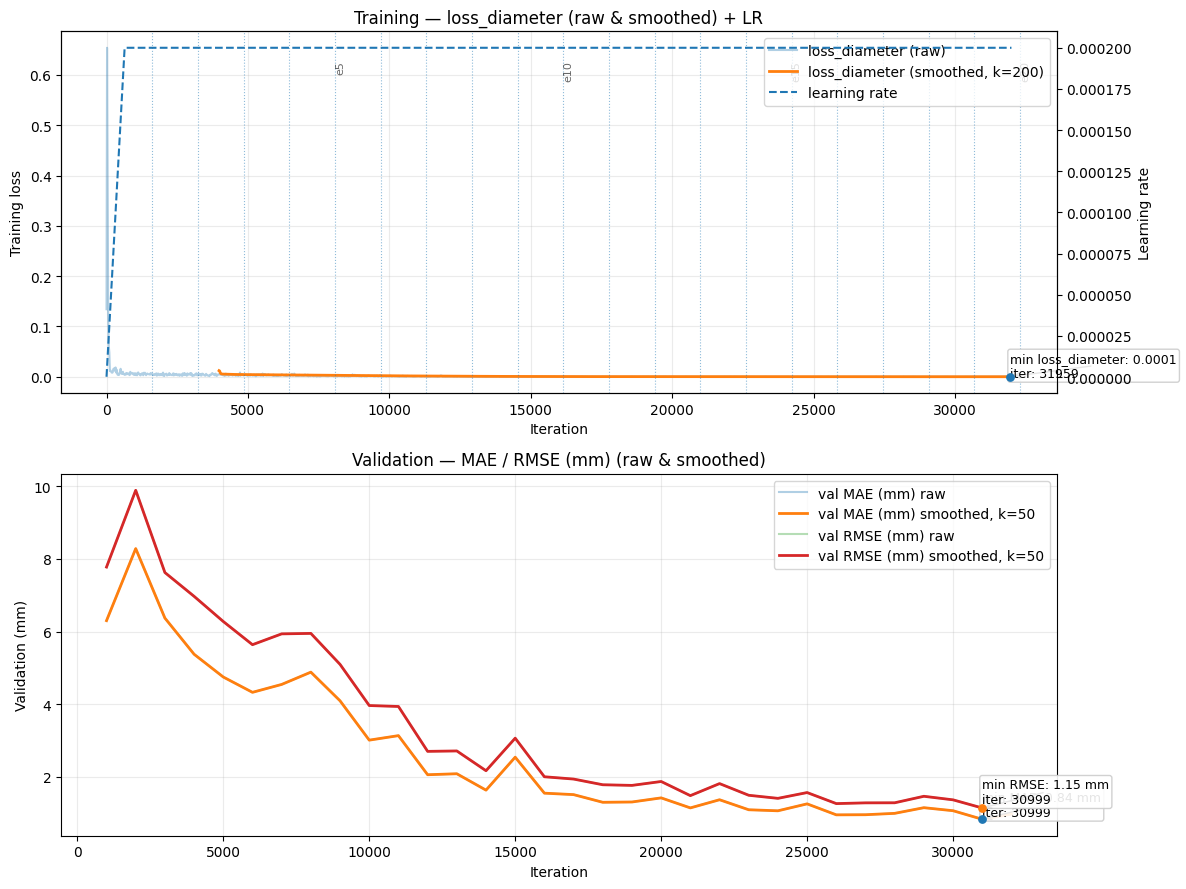

In [ ]:
# Plot Detectron2 metrics.json:
#  Top: train loss (raw + smoothed) + LR (twin axis)
#  Bottom: validation MAE/RMSE in mm (raw + smoothed) with minima
# Also supports epoch markers if N_IMAGES and BATCH are set.

import os, json
import numpy as np
import matplotlib.pyplot as plt

# ================= CONFIG (EDIT ME) =================
METRICS_PATH  = "/content/drive/MyDrive/snapshots_dataset/output_rgbd/metrics.json"
SMOOTH_LOSS   = 200     # window for training loss smoothing (iterations)
SMOOTH_VAL    = 50      # window for val MAE/RMSE smoothing (iterations)
N_IMAGES      = 3230    # set 0 to disable epoch markers
BATCH         = 2       # IMS_PER_BATCH
LOSS_KEY      = "loss_diameter"  # 'auto' | 'loss_diameter' | 'total_loss' | <any key>
SAVE_PNG      = True
# =====================================================

def load_records(metrics_path):
    recs = []
    with open(metrics_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                recs.append(json.loads(line))
            except json.JSONDecodeError:
                # ignore partially written line
                continue
    if not recs:
        raise ValueError(f"No valid JSON lines found in {metrics_path}")
    # Deduplicate by iteration keeping the LAST entry for each iteration
    by_iter = {}
    for r in recs:
        it = r.get("iteration")
        if it is not None:
            by_iter[it] = r
    if by_iter:
        recs = [by_iter[k] for k in sorted(by_iter.keys())]
    return recs

def moving_average(y, k):
    y = np.asarray(y, dtype=float)
    if k is None or k <= 1 or len(y) < k:
        return y, np.arange(len(y))
    kernel = np.ones(k, dtype=float) / k
    sm = np.convolve(y, kernel, mode="valid")
    idx = np.arange(k - 1, k - 1 + len(sm))
    return sm, idx

def autodetect_loss_key(recs, preferred=("loss_diameter", "total_loss")):
    if LOSS_KEY != "auto":
        return LOSS_KEY
    keys = set()
    for r in recs:
        keys.update(r.keys())
    for k in preferred:
        if k in keys:
            return k
    losslike = sorted([k for k in keys if "loss" in k.lower()])
    if not losslike:
        raise KeyError("No loss-like keys found in metrics.json")
    return losslike[0]

def extract_series(recs, loss_key):
    it_loss, loss = [], []
    it_lr, lr = [], []
    it_mae, mae = [], []
    it_rmse, rmse = [], []

    for r in recs:
        it = r.get("iteration", None)
        if it is None:
            continue

        if loss_key in r:
            it_loss.append(it); loss.append(r[loss_key])

        if "lr" in r:
            it_lr.append(it); lr.append(r["lr"])

        # custom keys from PeriodicValHook (mm)
        if "val_mae_mm" in r:
            it_mae.append(it); mae.append(r["val_mae_mm"])
        if "val_rmse_mm" in r:
            it_rmse.append(it); rmse.append(r["val_rmse_mm"])

    return (
        np.asarray(it_loss),  np.asarray(loss, dtype=float),
        np.asarray(it_lr),    np.asarray(lr,   dtype=float),
        np.asarray(it_mae),   np.asarray(mae,  dtype=float),
        np.asarray(it_rmse),  np.asarray(rmse, dtype=float),
    )

def plot_all(metrics_path, smooth_loss=200, smooth_val=50, n_images=0, batch=0, save_png=True):
    recs = load_records(metrics_path)
    loss_key = autodetect_loss_key(recs)

    (iters_loss, losses,
     iters_lr, lrs,
     iters_mae, maes,
     iters_rmse, rmses) = extract_series(recs, loss_key)

    if len(iters_loss) == 0:
        raise ValueError(f"No entries with '{loss_key}' found in {metrics_path}")

    # Smoothing
    loss_sm, idx_loss_sm = moving_average(losses, smooth_loss)
    it_loss_sm = iters_loss[idx_loss_sm] if len(idx_loss_sm) else np.array([])

    mae_sm,  idx_mae_sm  = moving_average(maes,  smooth_val) if len(maes)  else (np.array([]), np.array([]))
    it_mae_sm = iters_mae[idx_mae_sm] if len(idx_mae_sm) else np.array([])

    rmse_sm, idx_rmse_sm = moving_average(rmses, smooth_val) if len(rmses) else (np.array([]), np.array([]))
    it_rmse_sm = iters_rmse[idx_rmse_sm] if len(idx_rmse_sm) else np.array([])

    # Figure
    fig = plt.figure(figsize=(12, 9))

    # -------------- Top: Loss + LR --------------
    ax1 = plt.subplot(2, 1, 1)
    ax1.plot(iters_loss, losses, label=f"{loss_key} (raw)", alpha=0.35)
    if len(it_loss_sm):
        ax1.plot(it_loss_sm, loss_sm, label=f"{loss_key} (smoothed, k={smooth_loss})", linewidth=2)
        i_min = int(np.argmin(loss_sm))
        ax1.scatter([it_loss_sm[i_min]], [loss_sm[i_min]], s=28, zorder=5)
        ax1.annotate(
            f"min {loss_key}: {loss_sm[i_min]:.4f}\niter: {int(it_loss_sm[i_min])}",
            xy=(it_loss_sm[i_min], loss_sm[i_min]),
            xytext=(it_loss_sm[i_min], loss_sm[i_min] * 1.18),
            arrowprops=dict(arrowstyle="->", lw=1),
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", fc="w", ec="0.8", alpha=0.9),
        )
    ax1.set_xlabel("Iteration"); ax1.set_ylabel("Training loss"); ax1.grid(True, alpha=0.25)

    # LR on twin axis
    if len(iters_lr):
        ax1b = ax1.twinx()
        ax1b.plot(iters_lr, lrs, linestyle="--", label="learning rate")
        ax1b.set_ylabel("Learning rate")
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax1b.get_legend_handles_labels()
        ax1.legend(h1 + h2, l1 + l2, loc="upper right")
    else:
        ax1.legend(loc="upper right")

    # epoch markers
    if (n_images > 0) and (batch > 0):
        it_per_epoch = float(n_images) / float(batch)
        if it_per_epoch > 0:
            x_max = max(iters_loss.max() if len(iters_loss) else 0,
                        iters_lr.max()   if len(iters_lr)   else 0)
            n_ep = int(np.ceil(x_max / it_per_epoch))
            y0, y1 = ax1.get_ylim()
            for e in range(1, n_ep + 1):
                x = e * it_per_epoch
                ax1.axvline(x=x, linestyle=":", linewidth=0.8, alpha=0.5)
                if e % 5 == 0:
                    ax1.text(x, y0 + 0.92*(y1-y0), f"e{e}",
                             rotation=90, fontsize=8, va="top", alpha=0.6)

    ax1.set_title(f"Training — {loss_key} (raw & smoothed) + LR")

    # -------------- Bottom: Val MAE/RMSE (mm) --------------
    ax2 = plt.subplot(2, 1, 2)
    plotted_any = False

    if len(iters_mae):
        ax2.plot(iters_mae, maes, label="val MAE (mm) raw", alpha=0.35)
        if len(it_mae_sm):
            ax2.plot(it_mae_sm, mae_sm, label=f"val MAE (mm) smoothed, k={SMOOTH_VAL}", linewidth=2)
            i_min_mae = int(np.argmin(mae_sm))
            ax2.scatter([it_mae_sm[i_min_mae]], [mae_sm[i_min_mae]], s=28, zorder=5)
            ax2.annotate(
                f"min MAE: {mae_sm[i_min_mae]:.2f} mm\niter: {int(it_mae_sm[i_min_mae])}",
                xy=(it_mae_sm[i_min_mae], mae_sm[i_min_mae]),
                xytext=(it_mae_sm[i_min_mae], mae_sm[i_min_mae] * 1.12),
                arrowprops=dict(arrowstyle="->", lw=1),
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", fc="w", ec="0.8", alpha=0.9),
            )
        plotted_any = True

    if len(iters_rmse):
        ax2.plot(iters_rmse, rmses, label="val RMSE (mm) raw", alpha=0.35)
        if len(it_rmse_sm):
            ax2.plot(it_rmse_sm, rmse_sm, label=f"val RMSE (mm) smoothed, k={SMOOTH_VAL}", linewidth=2)
            i_min_rmse = int(np.argmin(rmse_sm))
            ax2.scatter([it_rmse_sm[i_min_rmse]], [rmse_sm[i_min_rmse]], s=28, zorder=5)
            ax2.annotate(
                f"min RMSE: {rmse_sm[i_min_rmse]:.2f} mm\niter: {int(it_rmse_sm[i_min_rmse])}",
                xy=(it_rmse_sm[i_min_rmse], rmse_sm[i_min_rmse]),
                xytext=(it_rmse_sm[i_min_rmse], rmse_sm[i_min_rmse] * 1.12),
                arrowprops=dict(arrowstyle="->", lw=1),
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", fc="w", ec="0.8", alpha=0.9),
            )
        plotted_any = True

    if not plotted_any:
        ax2.text(0.5, 0.5, "No validation metrics found (val_mae_mm / val_rmse_mm)",
                 ha="center", va="center", transform=ax2.transAxes)
    ax2.set_xlabel("Iteration"); ax2.set_ylabel("Validation (mm)"); ax2.grid(True, alpha=0.25)
    ax2.legend(loc="upper right")
    ax2.set_title("Validation — MAE / RMSE (mm) (raw & smoothed)")

    plt.tight_layout()

    if save_png:
        out_png = os.path.join(os.path.dirname(metrics_path), "training_loss_lr_val_mm.png")
        plt.savefig(out_png, dpi=150)
        print(f"[plot] Saved: {out_png}")

    plt.show()

# ---- run ----
plot_all(
    METRICS_PATH,
    smooth_loss=SMOOTH_LOSS,
    smooth_val=SMOOTH_VAL,
    n_images=N_IMAGES,
    batch=BATCH,
    save_png=SAVE_PNG,
)

In [ ]:
#!/usr/bin/env python3
"""
Snapshot-style RGB-D training script (single file, no external imports).

- Config block at top (paths/hparams).
- COCO loader that keeps diameter + per-annotation depth_file, and remaps category_id contiguously.
- RGB-D mapper: no geometric augs, photometric only on RGB; depth in mm as 4th channel.
- ResNet50-FPN backbone patched for 4-channel input (early fusion, robust to re-runs).
- Inline DiameterROIHeads (@configurable): regress normalized diameter from RoI features + geometric cues
  [log_w, log_h, log_z, geom_mm_norm].
- Inline PeriodicValHook: MAE/RMSE on the validation set using GT boxes.

Assumptions:
- COCO annotations include: bbox, category_id, diameter_gt (or diameter_mm), depth_file
- Depth images are Z16 PNGs in millimetres.
"""

import os, json, random, math
from typing import Any, Dict, List
import numpy as np
import cv2
import torch
import torch.nn as nn
from torch.nn import functional as F

from detectron2 import model_zoo
from detectron2.config import get_cfg, configurable
from detectron2.engine import DefaultTrainer, HookBase, default_setup
from detectron2.data import (
    DatasetCatalog, MetadataCatalog,
    build_detection_train_loader, build_detection_test_loader,
    detection_utils as utils, transforms as T,
)
from detectron2.structures import Instances, Boxes, BoxMode
from detectron2.utils.events import CommonMetricPrinter, JSONWriter

from detectron2.modeling.backbone import BACKBONE_REGISTRY
from detectron2.modeling.backbone.resnet import BasicStem
from detectron2.modeling.backbone.fpn import build_resnet_fpn_backbone
from detectron2.modeling.poolers import ROIPooler
from detectron2.modeling.roi_heads import ROIHeads, ROI_HEADS_REGISTRY
from detectron2.layers import Conv2d
from detectron2.checkpoint import DetectionCheckpointer


# =========================================================
# ===================== CONFIG BLOCK ======================
# =========================================================
TRAIN_JSON   = "/content/drive/MyDrive/snapshots_dataset/annotations/instances_Train.json"
EVAL_JSON    = "/content/drive/MyDrive/snapshots_dataset/annotations/instances_Eval.json"
IMG_ROOT     = "/content/drive/MyDrive/snapshots_dataset/rgb"
DEPTH_ROOT   = "/content/drive/MyDrive/snapshots_dataset/depth"
# ===== TEST CONFIG =====
TEST_JSON       = "/content/drive/MyDrive/test_dataset/annotations/instances_Test.json"
TEST_IMG_ROOT   = "/content/drive/MyDrive/test_dataset/rgb"
TEST_DEPTH_ROOT = "/content/drive/MyDrive/test_dataset/depth"

EVAL_ONLY_FROM_CHECKPOINT = True
CHECKPOINT_PATH = "/content/drive/MyDrive/snapshots_dataset/output_rgbd/model_final.pth"

OUTPUT_DIR   = "/content/drive/MyDrive/snapshots_dataset/output_rgbd"
MAX_ITER     = 32000
BATCH        = 2
BASE_LR      = 2e-4
WARMUP_FRAC  = 0.02
EVAL_PERIOD  = 1000
SEED         = 42

# Camera / geometry
FX_PX        = 600.0
SCALE_MM     = 73.35

# Augmentations: snapshot style (no geometry, solo photometric su RGB)
ENABLE_PHOTOMETRIC = True

# 4th channel normalization (depth in mm) — dai tuoi valori stimati
PIXEL_MEAN = [103.53, 116.28, 123.675, 192.723]
PIXEL_STD  = [57.375, 57.12,  58.395,  80.738]

# ROI head settings
POOLER_RESOLUTION = 14
HIDDEN_DIM = 1024
HIDDEN_DIM_2 = 256
HUBER_DELTA = 1.0           # Huber loss delta su unità normalizzate
RESIDUAL_L2 = 0.0           # >0 per spingere residual piccolo rispetto al prior geometrico
DROPOUT_P   = 0.0
# =========================================================


# ===== category mapping (global) =====
_ID_TO_CONTIG = None        # es. {1:0, 3:1, ...}
_THING_CLASSES = None       # es. ["apple"] in ordine contiguo

def _build_category_mapping(json_path: str):
    """Legge categories dal COCO e costruisce:
       - _ID_TO_CONTIG: mappa id COCO -> indice contiguo [0..K-1]
       - _THING_CLASSES: nomi in ordine contiguo
    """
    global _ID_TO_CONTIG, _THING_CLASSES
    with open(json_path, "r") as f:
        coco = json.load(f)

    cats = coco.get("categories", [])
    if not cats:
        # fallback: singola classe 'apple'
        _ID_TO_CONTIG = {0: 0, 1: 0}
        _THING_CLASSES = ["apple"]
        return

    cats_sorted = sorted(cats, key=lambda c: c.get("id", 0))
    _ID_TO_CONTIG = {c["id"]: i for i, c in enumerate(cats_sorted)}
    _THING_CLASSES = [c.get("name", str(c["id"])) for c in cats_sorted]


# ---------------------- dataset loader ----------------------
def load_coco_with_diameter(json_path: str, img_root: str) -> List[Dict[str, Any]]:
    with open(json_path, "r") as f:
        coco = json.load(f)

    imgs = {im["id"]: im for im in coco["images"]}
    anns_by_img: Dict[int, List[Dict[str, Any]]] = {}
    for ann in coco["annotations"]:
        if ann.get("iscrowd", 0) == 1:
            continue
        if "bbox" not in ann or len(ann["bbox"]) != 4:
            continue

        if "diameter_mm" in ann:
            dmm = float(ann["diameter_mm"])
        elif "diameter_gt" in ann:
            dmm = float(ann["diameter_gt"])
        else:
            continue

        # ---- remap category_id to contiguous ----
        raw_cid = ann.get("category_id", 0)
        cid = _ID_TO_CONTIG.get(raw_cid, 0) if _ID_TO_CONTIG is not None else 0

        depth_file = ann.get("depth_file", None)
        anns_by_img.setdefault(ann["image_id"], []).append({
            "bbox": ann["bbox"],
            "category_id": cid,
            "diameter_mm": dmm,
            "depth_file": depth_file,
        })

    dataset = []
    for img_id, im in imgs.items():
        file_name = os.path.join(img_root, im["file_name"])
        rec = {
            "file_name": file_name,
            "image_id": img_id,
            "height": im["height"],
            "width":  im["width"],
            "annotations": anns_by_img.get(img_id, []),
        }
        dfs = [a["depth_file"] for a in rec["annotations"] if a.get("depth_file")]
        if dfs:
            rec["depth_file"] = dfs[0]
        dataset.append(rec)
    return dataset


# ------------------------ helpers ------------------------
def _to_single_channel(arr: np.ndarray) -> np.ndarray:
    """Force depth to 2D: squeeze 1-channel or take channel 0 if 3-channel/colorized."""
    if arr is None:
        return None
    a = np.asarray(arr)
    # If colorized (HxWx3 or more), take first channel
    if a.ndim == 3 and a.shape[2] >= 3:
        a = a[..., 0]
    # Squeeze leftover singleton dims (HxWx1 -> HxW, HxWx1x1 -> HxW, etc.)
    if a.ndim > 2:
        a = np.squeeze(a)
    return a

def _read_depth_mm(path: str) -> np.ndarray:
    """Read depth PNG; return float32 millimetres; zeros→NaN. Robust to 3-ch colorized files."""
    if not path:
        return None
    d = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if d is None:
        return None
    d = _to_single_channel(d)
    dm = d.astype(np.float32)
    dm[dm == 0] = np.nan
    return dm

def _read_depth_m(path: str) -> np.ndarray:
    """Meters (for geometric cues). Robust to 3-ch colorized files."""
    if not path:
        return None
    d = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if d is None:
        return None
    d = _to_single_channel(d)
    dm = d.astype(np.float32)
    if dm.max() > 50.0:
        dm = dm / 1000.0
    return dm

def _resize_depth_like(depth_arr: np.ndarray, H: int, W: int) -> np.ndarray:
    if depth_arr is None:
        return None
    return cv2.resize(depth_arr, (W, H), interpolation=cv2.INTER_NEAREST)

def _depth_stat_in_box(depth_m: np.ndarray, x: float, y: float, w: float, h: float,
                       H: int, W: int) -> float:
    x0 = max(int(x), 0); y0 = max(int(y), 0)
    x1 = min(int(x + w), W); y1 = min(int(y + h), H)
    if x1 <= x0 or y1 <= y0 or depth_m is None:
        return 0.0
    crop = depth_m[y0:y1, x0:x1]
    v = crop[np.isfinite(crop) & (crop > 0)]
    if v.size == 0:
        return 0.0
    return float(np.median(v))

def _pinhole_mm(px_w: float, z_m: float, fx_px: float) -> float:
    if z_m <= 0.0 or fx_px <= 0.0: return 0.0
    return float(px_w * (z_m / fx_px) * 1000.0)

def _numpy_to_torch_state_dict(sd):
    """
    Detectron2 model_zoo checkpoints (.pkl) often store params as NumPy arrays.
    Convert all leaves to torch.Tensor so load_state_dict() accepts them.
    Accepts either a flat dict or a dict with key 'model'.
    Returns a flat dict of torch.Tensors.
    """
    if "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]

    out = {}
    for k, v in sd.items():
        if isinstance(v, torch.Tensor):
            out[k] = v
        elif isinstance(v, np.ndarray):
            out[k] = torch.from_numpy(v)
        else:
            try:
                out[k] = torch.as_tensor(v)
            except Exception:
                continue
    return out


# -------------------- RGB-D mapper (snapshot style) --------------------
def mapper_rgbd(dataset_dict: Dict[str, Any]) -> Dict[str, Any]:
    d = dataset_dict.copy()
    rgb_bgr = utils.read_image(d["file_name"], format="BGR").astype(np.float32)
    H, W = rgb_bgr.shape[:2]

    # Photometric-only on RGB
    if ENABLE_PHOTOMETRIC:
        aug = T.AugmentationList([
            T.RandomBrightness(0.9, 1.1),
            T.RandomContrast(0.9, 1.1),
            T.RandomSaturation(0.9, 1.1),
        ])
        ain = T.AugInput(rgb_bgr)
        _ = aug(ain)
        rgb_bgr = ain.image

    # Depth path (relative to DEPTH_ROOT if not absolute)
    dp = d.get("depth_file")
    depth_path = None
    if dp:
        depth_path = dp if os.path.isabs(dp) else os.path.join(DEPTH_ROOT, dp)

    # ---- Depth channel in mm (robusto a 3-ch, 1x1, ecc.) ----
    depth_mm = _read_depth_mm(depth_path)
    depth_mm = _resize_depth_like(depth_mm, H, W)
    if depth_mm is None:
        depth_mm = np.full((H, W), np.nan, dtype=np.float32)
    else:
        depth_mm = np.asarray(depth_mm)
        # se 3-ch (colorized), usa il primo canale; squeeze il resto
        if depth_mm.ndim == 3 and depth_mm.shape[2] >= 3:
            depth_mm = depth_mm[..., 0]
        if depth_mm.ndim > 2:
            depth_mm = np.squeeze(depth_mm)
        if depth_mm.ndim != 2:
            if depth_mm.size == H * W:
                depth_mm = depth_mm.reshape(H, W)
            else:
                depth_mm = cv2.resize(depth_mm.astype(np.float32), (W, H), interpolation=cv2.INTER_NEAREST)
        depth_mm = depth_mm.astype(np.float32)

    # riempi NaN con mediana (o 0 se tutto NaN)
    if np.isnan(depth_mm).any():
        med = np.nanmedian(depth_mm) if np.isfinite(depth_mm).any() else 0.0
        depth_mm = np.where(np.isnan(depth_mm), med, depth_mm)

    # ---- Build [4,H,W] senza concatenate (evita mismatch dimensioni) ----
    rgb_rgb = cv2.cvtColor(rgb_bgr.astype(np.uint8), cv2.COLOR_BGR2RGB).astype(np.float32)  # [H,W,3]
    rgbd = np.empty((H, W, 4), dtype=np.float32)
    rgbd[..., :3] = rgb_rgb
    rgbd[..., 3]  = depth_mm
    image = torch.as_tensor(rgbd.transpose(2, 0, 1))  # [4,H,W]

    # Normalize
    mean = torch.tensor(np.array(PIXEL_MEAN, dtype=np.float32).reshape(4,1,1))
    std  = torch.tensor(np.array(PIXEL_STD,  dtype=np.float32).reshape(4,1,1))
    image = (image - mean) / std

    # ---- Instances + geometric cues (depth in meters con stesso forcing) ----
    annos = []
    xyxy  = []
    cues  = []  # [log_w, log_h, log_z, geom_mm_norm]
    depth_m = _read_depth_m(depth_path)
    depth_m = _resize_depth_like(depth_m, H, W)
    if depth_m is not None:
        depth_m = np.asarray(depth_m)
        if depth_m.ndim == 3 and depth_m.shape[2] >= 3:
            depth_m = depth_m[..., 0]
        if depth_m.ndim > 2:
            depth_m = np.squeeze(depth_m)
        if depth_m.ndim != 2:
            if depth_m.size == H * W:
                depth_m = depth_m.reshape(H, W)
            else:
                depth_m = cv2.resize(depth_m.astype(np.float32), (W, H), interpolation=cv2.INTER_NEAREST)
        depth_m = depth_m.astype(np.float32)

    for a in d.get("annotations", []):
        x, y, w, h = a["bbox"]
        xyxy.append([x, y, x+w, y+h])

        gt_d_norm = float(a["diameter_mm"]) / SCALE_MM
        z_m = _depth_stat_in_box(depth_m, x, y, w, h, H, W) if depth_m is not None else 0.0
        log_z = float(np.log(max(z_m, 1e-6)))
        geom_mm = _pinhole_mm(w, z_m, FX_PX)
        geom_norm = float(geom_mm / SCALE_MM)

        cues.append([np.log(max(w,1e-6)), np.log(max(h,1e-6)), log_z, geom_norm])
        annos.append({
            "bbox": [x, y, w, h],
            "bbox_mode": BoxMode.XYWH_ABS,
            "category_id": a.get("category_id", 0),
            "diameter_norm": gt_d_norm
        })

    instances = utils.annotations_to_instances(annos, (H, W))
    if xyxy:
        instances.gt_boxes = Boxes(torch.tensor(xyxy, dtype=torch.float32))
        instances.set("diameter_norm", torch.tensor([a["diameter_norm"] for a in annos], dtype=torch.float32))
        instances.set("geom_cues",     torch.tensor(cues, dtype=torch.float32))

    d["image"] = image
    d["instances"] = instances
    return d


# ---------------------- 4-ch ResNet-FPN backbone ----------------------
class BasicStem4(BasicStem):
    def __init__(self, in_channels=4, out_channels=64, norm="FrozenBN"):
        super().__init__(in_channels=in_channels, out_channels=out_channels, norm=norm)

@BACKBONE_REGISTRY.register()
def build_resnet_fpn_backbone_rgbd_v1(cfg, input_shape):
    """
    Build a ResNet-FPN backbone then patch bottom_up.stem.conv1 to 4 channels, robustly.
    """
    backbone = build_resnet_fpn_backbone(cfg, input_shape)  # FPN
    old_conv: nn.Conv2d = backbone.bottom_up.stem.conv1

    out_ch  = old_conv.out_channels
    k, s, p, d = old_conv.kernel_size, old_conv.stride, old_conv.padding, old_conv.dilation
    bias = old_conv.bias is not None

    new_conv = Conv2d(
        in_channels=4,
        out_channels=out_ch,
        kernel_size=k,
        stride=s,
        padding=p,
        dilation=d,
        bias=bias,
        norm=None,
        activation=None,
    )

    with torch.no_grad():
        w_old = old_conv.weight  # [out_ch, Cin_old, k, k]
        Cin_old = w_old.shape[1]
        if Cin_old == 3:
            new_conv.weight[:, :3, :, :] = w_old
            new_conv.weight[:, 3:4, :, :] = w_old.mean(dim=1, keepdim=True)
        elif Cin_old == 4:
            new_conv.weight.copy_(w_old)
        else:
            c = min(Cin_old, 4)
            new_conv.weight[:, :c, :, :] = w_old[:, :c, :, :]
            fill = w_old.mean(dim=1, keepdim=True)
            if c < 4:
                new_conv.weight[:, c:4, :, :] = fill
        if bias and old_conv.bias is not None:
            new_conv.bias.copy_(old_conv.bias)

    backbone.bottom_up.stem.conv1 = new_conv

    print(f"[DEBUG] bottom_up.stem.conv1 weight shape -> {backbone.bottom_up.stem.conv1.weight.shape}")
    print(f"[DEBUG] FPN output features -> {list(backbone.output_shape().keys())}")
    return backbone


# ---------------------- ROI HEAD (INLINE, @configurable) ----------------------
@ROI_HEADS_REGISTRY.register()
class DiameterROIHeads(ROIHeads):
    """
    Minimal ROI heads that:
     - use GT boxes during training (no RPN interaction),
     - pool FPN features over GT boxes,
     - fuse pooled features + geometric cues and predict normalized diameter,
     - compute Smooth L1 (Huber) on normalized units; optional L2 on residual vs geom prior.
    """

    @configurable
    def __init__(self, *, cfg, input_shape, **kwargs):
        # Base ROIHeads expects kwargs from ROIHeads.from_config(cfg)
        super().__init__(**kwargs)

        self.in_features = cfg.MODEL.ROI_HEADS.IN_FEATURES
        self.pooler = ROIPooler(
            output_size=cfg.MODEL.ROI_BOX_HEAD.POOLER_RESOLUTION,
            scales=tuple(1.0 / input_shape[f].stride for f in self.in_features),
            sampling_ratio=cfg.MODEL.ROI_BOX_HEAD.POOLER_SAMPLING_RATIO,
            pooler_type=cfg.MODEL.ROI_BOX_HEAD.POOLER_TYPE,
        )
        in_channels = [input_shape[f].channels for f in self.in_features][0]
        rep = cfg.MODEL.ROI_BOX_HEAD.POOLER_RESOLUTION
        flat_dim = in_channels * rep * rep

        self.mlp = nn.Sequential(
            nn.Linear(flat_dim + 4, HIDDEN_DIM),
            nn.ReLU(inplace=True),
            nn.Dropout(p=DROPOUT_P) if DROPOUT_P > 0 else nn.Identity(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM_2),
            nn.ReLU(inplace=True),
            nn.Linear(HIDDEN_DIM_2, 1),
        )

        self.huber_delta = HUBER_DELTA
        self.residual_l2 = RESIDUAL_L2

    @classmethod
    def from_config(cls, cfg, input_shape=None):
        base_kwargs = ROIHeads.from_config(cfg)          # version that takes only cfg
        base_kwargs.update({"cfg": cfg, "input_shape": input_shape})
        return base_kwargs

    def _pool(self, features, boxes):
        feats = [features[f] for f in self.in_features]
        return self.pooler(feats, boxes)

    def forward(self, images, features, proposals, targets=None):
        train = self.training
        insts = targets if train and targets is not None else proposals

        boxes = [i.gt_boxes if i.has("gt_boxes") else i.proposal_boxes for i in insts]
        pooled = self._pool(features, boxes)
        N = pooled.shape[0]
        if N == 0:
            return proposals, {} if train else (proposals, [])

        x = pooled.flatten(start_dim=1)
        if not insts[0].has("geom_cues"):
            raise ValueError("Instances missing 'geom_cues' field.")
        cues = torch.cat([i.get("geom_cues") for i in insts], dim=0)
        x = torch.cat([x, cues.to(x.device)], dim=1)

        pred = self.mlp(x).squeeze(1)

        if train:
            if not insts[0].has("diameter_norm"):
                raise ValueError("Instances missing 'diameter_norm' field.")
            target = torch.cat([i.get("diameter_norm") for i in insts], dim=0).to(pred.device)

            loss = F.smooth_l1_loss(pred, target, beta=self.huber_delta, reduction="mean")

            if self.residual_l2 > 0:
                geom = torch.cat([i.get("geom_cues") for i in insts], dim=0)[:, 3].to(pred.device)
                residual = pred - geom
                loss = loss + self.residual_l2 * torch.mean(residual * residual)

            return proposals, {"loss_diameter": loss}

        out = []
        idx = 0
        for inst in proposals:
            m = len(inst)
            if m == 0:
                out.append(inst); continue
            new_inst = Instances(inst.image_size, **inst.get_fields())
            d_norm = pred[idx:idx+m]
            d_mm = d_norm * SCALE_MM
            new_inst.set("pred_diameter_mm", d_mm.detach().cpu())
            out.append(new_inst)
            idx += m

        return out, {}


# ------------------------- trainer -------------------------
class MyTrainer(DefaultTrainer):
    @classmethod
    def build_train_loader(cls, cfg):
        return build_detection_train_loader(cfg, mapper=mapper_rgbd)

    def build_writers(self):
        os.makedirs(self.cfg.OUTPUT_DIR, exist_ok=True)
        return [
            CommonMetricPrinter(max_iter=self.cfg.SOLVER.MAX_ITER),
            JSONWriter(os.path.join(self.cfg.OUTPUT_DIR, "metrics.json")),
        ]


# --------------------- validation hook ---------------------
class PeriodicValHook(HookBase):
    def __init__(self, eval_period, json_path, img_root):
        self._period = eval_period
        self._json   = json_path
        self._img_root = img_root
        self._name  = "apples_eval"

        if self._name not in DatasetCatalog.list():
            DatasetCatalog.register(self._name, lambda: load_coco_with_diameter(self._json, self._img_root))
            MetadataCatalog.get(self._name).set(thing_classes=_THING_CLASSES or ["apple"])

    def after_step(self):
        next_iter = self.trainer.iter + 1
        if (self._period > 0) and (next_iter % self._period == 0 or next_iter == self.trainer.max_iter):
            self._run_eval()

    @torch.no_grad()
    def _run_eval(self):
        model = self.trainer.model
        model.eval()
        cfg = self.trainer.cfg
        val_loader = build_detection_test_loader(cfg, self._name, mapper=mapper_rgbd)

        abs_errs, sq_errs, n = 0.0, 0.0, 0
        for batch in val_loader:
            inputs = [{"image": b["image"], "instances": b["instances"]} for b in batch]
            images = model.preprocess_image(inputs)           # ImageList
            features = model.backbone(images.tensor)          # dict of FPN features

            targets = [x["instances"].to(images.tensor.device) for x in inputs]
            pred_insts, _ = model.roi_heads(images, features, proposals=targets, targets=targets)
            for tgt, pred in zip(targets, pred_insts):
                gt = tgt.get("diameter_norm") * SCALE_MM  # mm
                pr = pred.get("pred_diameter_mm")
                if gt is None or pr is None:
                    continue
                gt = gt.detach().cpu().numpy().astype(np.float32)
                pr = pr.detach().cpu().numpy().astype(np.float32)
                abs_errs += float(np.abs(pr - gt).sum())
                sq_errs  += float(((pr - gt) ** 2).sum())
                n        += gt.shape[0]

        if n > 0:
            mae = abs_errs / n
            rmse = math.sqrt(sq_errs / n)
            print(f"[Val] MAE(mm)={mae:.3f}  RMSE(mm)={rmse:.3f}  (N={n})")
            storage = self.trainer.storage
            storage.put_scalar("val_mae_mm", mae)
            storage.put_scalar("val_rmse_mm", rmse)

        model.train()

@torch.no_grad()
def run_eval_split(trainer, dataset_name: str, depth_root: str, tag: str = "eval"):
    """
    Esegue la stessa valutazione del PeriodicValHook, ma su un dataset arbitrario
    (es. 'apples_test'), riutilizzando mapper_rgbd, cues, ROIHead, ecc.
    Stampa MAE/RMSE in mm.
    """
    model = trainer.model
    model.eval()
    cfg = trainer.cfg

    # Cambiamo temporaneamente la root della depth
    global DEPTH_ROOT
    old_depth_root = DEPTH_ROOT
    DEPTH_ROOT = depth_root

    val_loader = build_detection_test_loader(cfg, dataset_name, mapper=mapper_rgbd)

    abs_errs, sq_errs, n = 0.0, 0.0, 0
    for batch in val_loader:
        # identico al PeriodicValHook._run_eval
        inputs = [{"image": b["image"], "instances": b["instances"]} for b in batch]
        images = model.preprocess_image(inputs)           # ImageList
        features = model.backbone(images.tensor)          # FPN features

        targets = [x["instances"].to(images.tensor.device) for x in inputs]
        # proposals = targets per dire al ROIHead di usare le GT boxes
        pred_insts, _ = model.roi_heads(
            images, features,
            proposals=targets,
            targets=targets
        )

        for tgt, pred in zip(targets, pred_insts):
            if (not tgt.has("diameter_norm")) or (not pred.has("pred_diameter_mm")):
                continue
            gt = tgt.get("diameter_norm") * SCALE_MM  # mm
            pr = pred.get("pred_diameter_mm")

            gt = gt.detach().cpu().numpy().astype(np.float32)
            pr = pr.detach().cpu().numpy().astype(np.float32)

            abs_errs += float(np.abs(pr - gt).sum())
            sq_errs  += float(((pr - gt) ** 2).sum())
            n        += gt.shape[0]

    # ripristina la root della depth per sicurezza
    DEPTH_ROOT = old_depth_root

    if n == 0:
        print(f"[{tag}-eval] N=0 (nessun GT valido trovato). "
              "Controlla che 'diameter_mm' sia presente nel COCO e che ci siano bbox.")
        return float("nan"), float("nan"), 0

    mae = abs_errs / n
    rmse = math.sqrt(sq_errs / n)
    print(f"[{tag}-eval] N={n} | MAE={mae:.3f} mm | RMSE={rmse:.3f} mm")
    return mae, rmse, n

# ------------------------ config ---------------------------
def build_cfg():
    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
    cfg = get_cfg()
    cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))

    # 4-ch ResNet-FPN backbone
    cfg.MODEL.BACKBONE.NAME = "build_resnet_fpn_backbone_rgbd_v1"

    # Replace ROI heads with our inline head
    cfg.MODEL.ROI_HEADS.NAME = "DiameterROIHeads"
    cfg.MODEL.ROI_HEADS.IN_FEATURES = ["p2", "p3", "p4", "p5"]  # FPN levels
    cfg.MODEL.ROI_BOX_HEAD.POOLER_RESOLUTION = POOLER_RESOLUTION
    cfg.MODEL.ROI_BOX_HEAD.POOLER_SAMPLING_RATIO = 0
    cfg.MODEL.ROI_BOX_HEAD.POOLER_TYPE = "ROIAlignV2"
    # cfg.MODEL.ROI_HEADS.NUM_CLASSES will be set in main() from _THING_CLASSES

    # 4-channel normalization
    cfg.MODEL.PIXEL_MEAN = PIXEL_MEAN
    cfg.MODEL.PIXEL_STD  = PIXEL_STD

    # Datasets
    cfg.DATASETS.TRAIN = ("apples_train",)
    cfg.DATASETS.TEST  = ()
    cfg.DATALOADER.NUM_WORKERS = 2

    # Solver
    cfg.SOLVER.IMS_PER_BATCH = BATCH
    cfg.SOLVER.BASE_LR = BASE_LR
    cfg.SOLVER.MAX_ITER = MAX_ITER
    cfg.SOLVER.WARMUP_ITERS = max(10, int(WARMUP_FRAC * MAX_ITER))
    cfg.SOLVER.STEPS = []  # flat LR

    # Image sizes
    cfg.INPUT.MIN_SIZE_TRAIN = (800,)
    cfg.INPUT.MAX_SIZE_TRAIN = 1333
    cfg.INPUT.MIN_SIZE_TEST  = 800
    cfg.INPUT.MAX_SIZE_TEST  = 1333

    # Pretrained weights
    cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")

    cfg.OUTPUT_DIR = OUTPUT_DIR
    os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
    return cfg


# -------------------------- main --------------------------
def _expand_conv1_in_state_dict_to_4ch(state_dict):
    """
    Espande i pesi conv1 da 3→4 canali prima del load, se necessario.
    Prova sia il path FPN (bottom_up) che quello semplice.
    """
    keys = [
        "backbone.bottom_up.stem.conv1.weight",  # FPN
        "backbone.stem.conv1.weight",            # non-FPN fallback
    ]
    for key in keys:
        w = state_dict.get(key, None)
        if isinstance(w, torch.Tensor) and w.ndim == 4 and w.shape[1] == 3:
            w4 = torch.zeros((w.shape[0], 4, w.shape[2], w.shape[3]), dtype=w.dtype)
            w4[:, :3, :, :] = w
            w4[:, 3:4, :, :] = w.mean(dim=1, keepdim=True)
            state_dict[key] = w4
            print(f"[DEBUG] Patched checkpoint conv1 3->4 channels at '{key}'")
    return state_dict

def main():
    # ---- build category map from TRAIN_JSON ----
    _build_category_mapping(TRAIN_JSON)
    assert _ID_TO_CONTIG is not None and _THING_CLASSES is not None

    # Register datasets (uses mapping)
    DatasetCatalog.clear()
    DatasetCatalog.register("apples_train", lambda: load_coco_with_diameter(TRAIN_JSON, IMG_ROOT))
    MetadataCatalog.get("apples_train").set(thing_classes=_THING_CLASSES)

    if EVAL_JSON and os.path.exists(EVAL_JSON):
        if "apples_eval" not in DatasetCatalog.list():
            DatasetCatalog.register("apples_eval", lambda: load_coco_with_diameter(EVAL_JSON, IMG_ROOT))
            MetadataCatalog.get("apples_eval").set(thing_classes=_THING_CLASSES)

    # Register TEST (se esiste)
    if TEST_JSON and os.path.exists(TEST_JSON):
        if "apples_test" not in DatasetCatalog.list():
            DatasetCatalog.register("apples_test", lambda: load_coco_with_diameter(TEST_JSON, TEST_IMG_ROOT))
            MetadataCatalog.get("apples_test").set(thing_classes=_THING_CLASSES)

    cfg = build_cfg()
    # Align NUM_CLASSES to categories
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(_THING_CLASSES)
    default_setup(cfg, {})

    trainer = MyTrainer(cfg)

    # ------------ RAMO SOLO EVAL DA CHECKPOINT ------------
    if EVAL_ONLY_FROM_CHECKPOINT:
        print(f"[EVAL-ONLY] Loading checkpoint: {CHECKPOINT_PATH}")
        from detectron2.checkpoint import DetectionCheckpointer
        checkpointer = DetectionCheckpointer(trainer.model)
        checkpointer.load(CHECKPOINT_PATH)
        trainer.model.eval()

        if TEST_JSON and os.path.exists(TEST_JSON):
            print("\n[TEST-EVAL] Running MAE/RMSE on apples_test ...")
            run_eval_split(trainer, "apples_test", TEST_DEPTH_ROOT, tag="test")
        else:
            print("[TEST-EVAL] TEST_JSON non trovato, salto la valutazione.")
        return
    # ------------------------------------------------------

    # ---- load pretrained weights with conv1 3->4 patch if needed ----
    trainer.model.train()  # ensure modules are built
    checkpointer = DetectionCheckpointer(trainer.model)

    raw_sd = checkpointer._load_file(cfg.MODEL.WEIGHTS)   # may contain NumPy arrays
    state_dict = _numpy_to_torch_state_dict(raw_sd)       # <- convert all to torch.Tensors
    state_dict = _expand_conv1_in_state_dict_to_4ch(state_dict)  # keep as torch tensors

    missing, unexpected = trainer.model.load_state_dict(state_dict, strict=False)
    print("[DEBUG] load_state_dict missing:", missing)
    print("[DEBUG] load_state_dict unexpected:", unexpected)

    # Debug sulla conv1 del modello finale e sulle feature FPN
    try:
        print(f"[DEBUG] model bottom_up.stem.conv1 weight shape -> {trainer.model.backbone.bottom_up.stem.conv1.weight.shape}")
        print(f"[DEBUG] model FPN features -> {list(trainer.model.backbone.output_shape().keys())}")
    except Exception as e:
        print("[DEBUG] cannot print FPN debug:", e)

    # --- Periodic validation with GT boxes (inserted before writers) ---
    if EVAL_JSON and os.path.exists(EVAL_JSON):
        val_hook = PeriodicValHook(EVAL_PERIOD, EVAL_JSON, IMG_ROOT)
        # Detectron2 mette i writer (CommonMetricPrinter e JSONWriter) alla fine,
        # quindi li spingiamo giù e inseriamo il val_hook prima di loro
        WRITERS_COUNT = 2
        trainer._hooks.insert(-WRITERS_COUNT, val_hook)

    trainer.train()

if __name__ == "__main__":
    main()

[11/03 18:28:25 detectron2]: Rank of current process: 0. World size: 1
[11/03 18:28:26 detectron2]: Environment info:
-------------------------------  -----------------------------------------------------------------
sys.platform                     linux
Python                           3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
numpy                            2.0.2
detectron2                       0.6 @/usr/local/lib/python3.12/dist-packages/detectron2
Compiler                         GCC 11.4
CUDA compiler                    CUDA 12.5
detectron2 arch flags            7.5
DETECTRON2_ENV_MODULE            <not set>
PyTorch                          2.8.0+cu126 @/usr/local/lib/python3.12/dist-packages/torch
PyTorch debug build              False
torch._C._GLIBCXX_USE_CXX11_ABI  True
GPU available                    Yes
GPU 0                            Tesla T4 (arch=7.5)
Driver version                   550.54.15
CUDA_HOME                        /usr/local/cuda
Pillow          

Using COCO json: /content/drive/MyDrive/test_dataset/annotations/instances_Test.json
RGB root:        /content/drive/MyDrive/test_dataset/rgb
Depth root:      /content/drive/MyDrive/test_dataset/depth
Enter COCO image id: 2

Image id:  2
RGB file:  /content/drive/MyDrive/test_dataset/rgb/TST_0002_Color.png
Depth file:/content/drive/MyDrive/test_dataset/depth/TST_0002_Depth.png
Annotations:
  - Apple 0: bbox=[711.7, 387.8, 103.9, 109.5], diameter_gt=73.40 mm


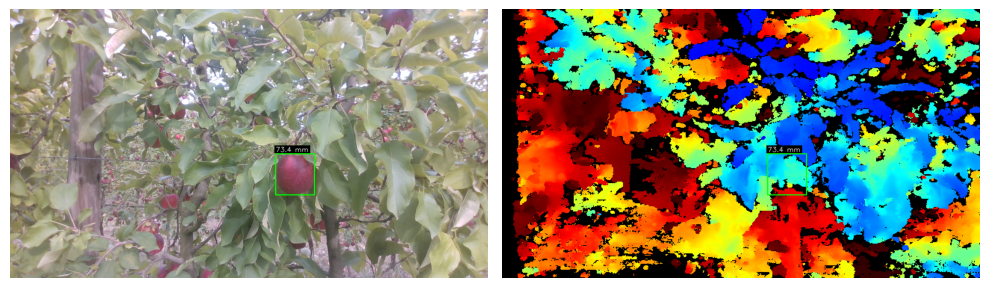

In [ ]:
#!/usr/bin/env python3

# ============================================================
# CONFIG BLOCK – EDIT THESE PATHS FOR YOUR COLAB ENVIRONMENT
# ============================================================
COCO_JSON = "/content/drive/MyDrive/test_dataset/annotations/instances_Test.json"   # path to your COCO annotation file
IMG_ROOT  = "/content/drive/MyDrive/test_dataset/rgb"           # directory containing RGB images
DEPTH_ROOT = "/content/drive/MyDrive/test_dataset/depth"        # directory containing depth images
# ============================================================

import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt


def load_coco(json_path):
    with open(json_path, "r") as f:
        return json.load(f)


def find_image_record(coco, image_id):
    for img in coco["images"]:
        if int(img["id"]) == int(image_id):
            return img
    return None


def collect_annotations(coco, image_id):
    return [a for a in coco["annotations"] if int(a["image_id"]) == int(image_id)]


def get_rgb_path(img_record, img_root):
    file_name = img_record["file_name"]
    if os.path.isabs(file_name):
        return file_name
    return os.path.join(img_root, file_name)


def get_depth_path(img_record, anns, depth_root):
    """
    depth_file can be at image level or annotation level.
    We try:
      1) img_record["depth_file"]
      2) anns[0]["depth_file"]
    """
    depth_rel = img_record.get("depth_file")
    if not depth_rel and len(anns) > 0:
        depth_rel = anns[0].get("depth_file")

    if not depth_rel:
        return None

    if os.path.isabs(depth_rel):
        return depth_rel
    return os.path.join(depth_root, depth_rel)


def make_depth_vis(depth_raw):
    """
    Convert a raw depth map to a nice 8-bit BGR image for display.

    Handles:
      - single-channel depth (uint16/float)
      - 3-channel depth (already colorized / BGR)
    """
    # Already 3-channel (e.g. colorized depth)
    if depth_raw.ndim == 3 and depth_raw.shape[2] == 3:
        depth = depth_raw.astype(np.float32)
        valid = depth > 0

        if np.any(valid):
            dmin = depth[valid].min()
            dmax = depth[valid].max()
            if dmax > dmin:
                depth_norm = (depth - dmin) / (dmax - dmin)
            else:
                depth_norm = np.zeros_like(depth)
        else:
            depth_norm = np.zeros_like(depth)

        depth_u8 = np.clip(depth_norm * 255.0, 0, 255).astype(np.uint8)
        # Already 3-channel
        return depth_u8

    # Single channel (or 1-channel in last dim)
    if depth_raw.ndim == 3 and depth_raw.shape[2] == 1:
        depth = depth_raw[..., 0].astype(np.float32)
    else:
        depth = depth_raw.astype(np.float32)

    valid = depth > 0
    if np.any(valid):
        dmin = depth[valid].min()
        dmax = depth[valid].max()
        if dmax > dmin:
            depth_norm = (depth - dmin) / (dmax - dmin)
        else:
            depth_norm = np.zeros_like(depth)
    else:
        depth_norm = np.zeros_like(depth)

    depth_u8 = np.clip(depth_norm * 255.0, 0, 255).astype(np.uint8)
    depth_bgr = cv2.cvtColor(depth_u8, cv2.COLOR_GRAY2BGR)
    return depth_bgr


def draw_bboxes_with_diameter(rgb_bgr, depth_bgr, anns):
    """
    Draw all bboxes and diameter_gt labels on both RGB and depth images.
    """
    rgb_out = rgb_bgr.copy()
    depth_out = depth_bgr.copy()

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.6
    thickness = 1
    color = (0, 255, 0)  # green boxes

    for ann in anns:
        x, y, w, h = ann["bbox"]  # COCO: x, y, w, h
        x0, y0 = int(x), int(y)
        x1, y1 = int(x + w), int(y + h)

        # ---- use diameter_gt (fallback to diameter_mm if needed) ----
        diam = float(ann.get("diameter_gt", ann.get("diameter_mm", 0.0)))
        label = f"{diam:.1f} mm"

        # Draw rectangle on both images
        cv2.rectangle(rgb_out, (x0, y0), (x1, y1), color, 2)
        cv2.rectangle(depth_out, (x0, y0), (x1, y1), color, 2)

        # Compute text size
        (tw, th), _ = cv2.getTextSize(label, font, font_scale, thickness)
        pad = 3

        # Text background above bbox (or inside if near top)
        text_x = x0
        text_y = y0 - 5
        if text_y - th - 2 < 0:
            text_y = y0 + th + 5

        bg_tl = (text_x - pad, text_y - th - pad)
        bg_br = (text_x + tw + pad, text_y + pad)

        # Draw background + text on both images
        for img in (rgb_out, depth_out):
            cv2.rectangle(img, bg_tl, bg_br, (0, 0, 0), -1)
            cv2.putText(img, label, (text_x, text_y), font, font_scale,
                        (255, 255, 255), thickness, cv2.LINE_AA)

    return rgb_out, depth_out


def main():
    print(f"Using COCO json: {COCO_JSON}")
    print(f"RGB root:        {IMG_ROOT}")
    print(f"Depth root:      {DEPTH_ROOT}")

    image_id_str = input("Enter COCO image id: ").strip()
    if not image_id_str:
        print("No image id provided, aborting.")
        return
    image_id = int(image_id_str)

    # ---- Load COCO ----
    if not os.path.exists(COCO_JSON):
        print(f"COCO file not found: {COCO_JSON}")
        return

    coco = load_coco(COCO_JSON)

    img_rec = find_image_record(coco, image_id)
    if img_rec is None:
        print(f"Image id {image_id} not found in COCO file.")
        return

    anns = collect_annotations(coco, image_id)
    if not anns:
        print(f"No annotations found for image id {image_id}.")
        return

    # ---- Load RGB ----
    rgb_path = get_rgb_path(img_rec, IMG_ROOT)
    rgb_bgr = cv2.imread(rgb_path, cv2.IMREAD_COLOR)
    if rgb_bgr is None:
        print(f"Could not read RGB image: {rgb_path}")
        return

    # ---- Load Depth ----
    depth_path = get_depth_path(img_rec, anns, DEPTH_ROOT)
    if depth_path is None:
        print("No depth_file field found for this image/annotations.")
        return

    depth_raw = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)
    if depth_raw is None:
        print(f"Could not read depth image: {depth_path}")
        return

    depth_vis_bgr = make_depth_vis(depth_raw)

    # ---- ALIGN DEPTH TO RGB SIZE (for correct bbox drawing) ----
    rh, rw = rgb_bgr.shape[:2]
    dh, dw = depth_vis_bgr.shape[:2]
    if (rh, rw) != (dh, dw):
        depth_vis_bgr = cv2.resize(
            depth_vis_bgr,
            (rw, rh),
            interpolation=cv2.INTER_NEAREST
        )

    # ---- Draw bboxes + labels ----
    rgb_drawn, depth_drawn = draw_bboxes_with_diameter(rgb_bgr, depth_vis_bgr, anns)

    # ---- Print info to console ----
    print(f"\nImage id:  {image_id}")
    print(f"RGB file:  {rgb_path}")
    print(f"Depth file:{depth_path}")
    print("Annotations:")
    for i, ann in enumerate(anns):
        x, y, w, h = ann["bbox"]
        diam = float(ann.get("diameter_gt", ann.get("diameter_mm", 0.0)))
        print(f"  - Apple {i}: bbox=[{x:.1f}, {y:.1f}, {w:.1f}, {h:.1f}], diameter_gt={diam:.2f} mm")

    # ---- Show images with matplotlib ----
    rgb_rgb = cv2.cvtColor(rgb_drawn, cv2.COLOR_BGR2RGB)
    depth_rgb = cv2.cvtColor(depth_drawn, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_rgb)
    #plt.title("RGB + diameter_gt")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(depth_rgb)
    #plt.title("Depth + diameter_gt")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()